In [18]:
%matplotlib inline

In [1]:
import pandas as pd

df = pd.read_csv("titanic.csv")

print("Titanic dataset loaded successfully!")
print("Shape:", df.shape)

Titanic dataset loaded successfully!
Shape: (889, 15)


In [2]:
X = df.drop(columns=["survived"])
y = df["survived"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (889, 14)
Target shape: (889,)


In [3]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numeric features:
['pclass', 'age', 'sibsp', 'parch', 'fare']

Categorical features:
['sex', 'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive', 'alone', 'age_group']


C:\Users\Admin\AppData\Local\Temp\ipykernel_14564\2134679766.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()


In [7]:
X = df.drop(columns=["survived", "alive", "class", "age_group"])
y = df["survived"]

print("Features:")
print(X.columns.tolist())

print("\nFeatures shape:", X.shape)
print("Target shape:", y.shape)

Features:
['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'who', 'adult_male', 'embark_town', 'alone']

Features shape: (889, 11)
Target shape: (889,)


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining survival rate:", y_train.mean())
print("Test survival rate:", y_test.mean())

Training set: (711, 11)
Test set: (178, 11)

Training survival rate: 0.38255977496483823
Test survival rate: 0.38202247191011235


In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


C:\Users\Admin\AppData\Local\Temp\ipykernel_14564\163345603.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(


In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

pipelines = {}

for name, model in models.items():
    pipelines[name] = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

print("Three classification pipelines created successfully!")

Three classification pipelines created successfully!


In [13]:
for name, pipeline in pipelines.items():
    pipeline.fit(X_train, y_train)
    print(f"{name} trained successfully!")

Logistic Regression trained successfully!
Decision Tree trained successfully!
Random Forest trained successfully!


In [14]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

results = []

for name, pipeline in pipelines.items():
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)

print(results_df.round(4))

                 Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
0  Logistic Regression    0.8146     0.7966  0.6912    0.7402   0.8678
1        Decision Tree    0.8034     0.7463  0.7353    0.7407   0.7850
2        Random Forest    0.7921     0.7385  0.7059    0.7218   0.8140


In [15]:
from sklearn.metrics import confusion_matrix

for name, pipeline in pipelines.items():
    y_pred = pipeline.predict(X_test)
    
    cm = confusion_matrix(y_test, y_pred)
    
    print(f"\n{name}")
    print(cm)


Logistic Regression
[[98 12]
 [21 47]]

Decision Tree
[[93 17]
 [18 50]]

Random Forest
[[93 17]
 [20 48]]


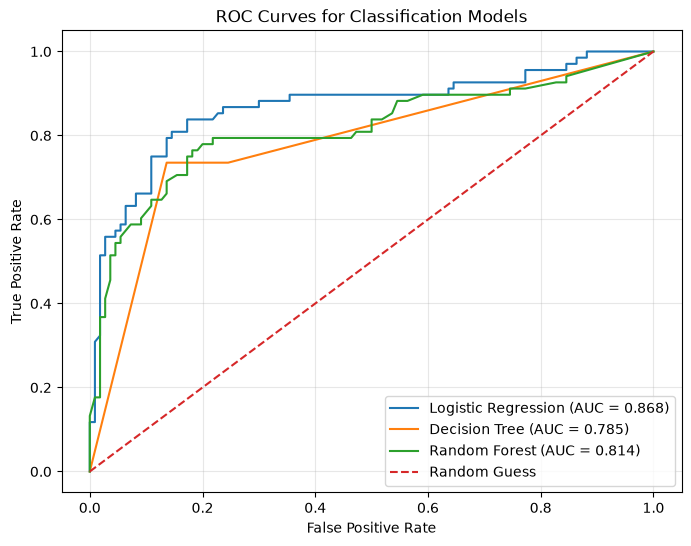

In [20]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

for name, pipeline in pipelines.items():
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Classification Models")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [21]:
for name, pipeline in pipelines.items():
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    auc_score = roc_auc_score(y_test, y_prob)
    
    print(f"{name}: AUC = {auc_score:.4f}")

Logistic Regression: AUC = 0.8678
Decision Tree: AUC = 0.7850
Random Forest: AUC = 0.8140


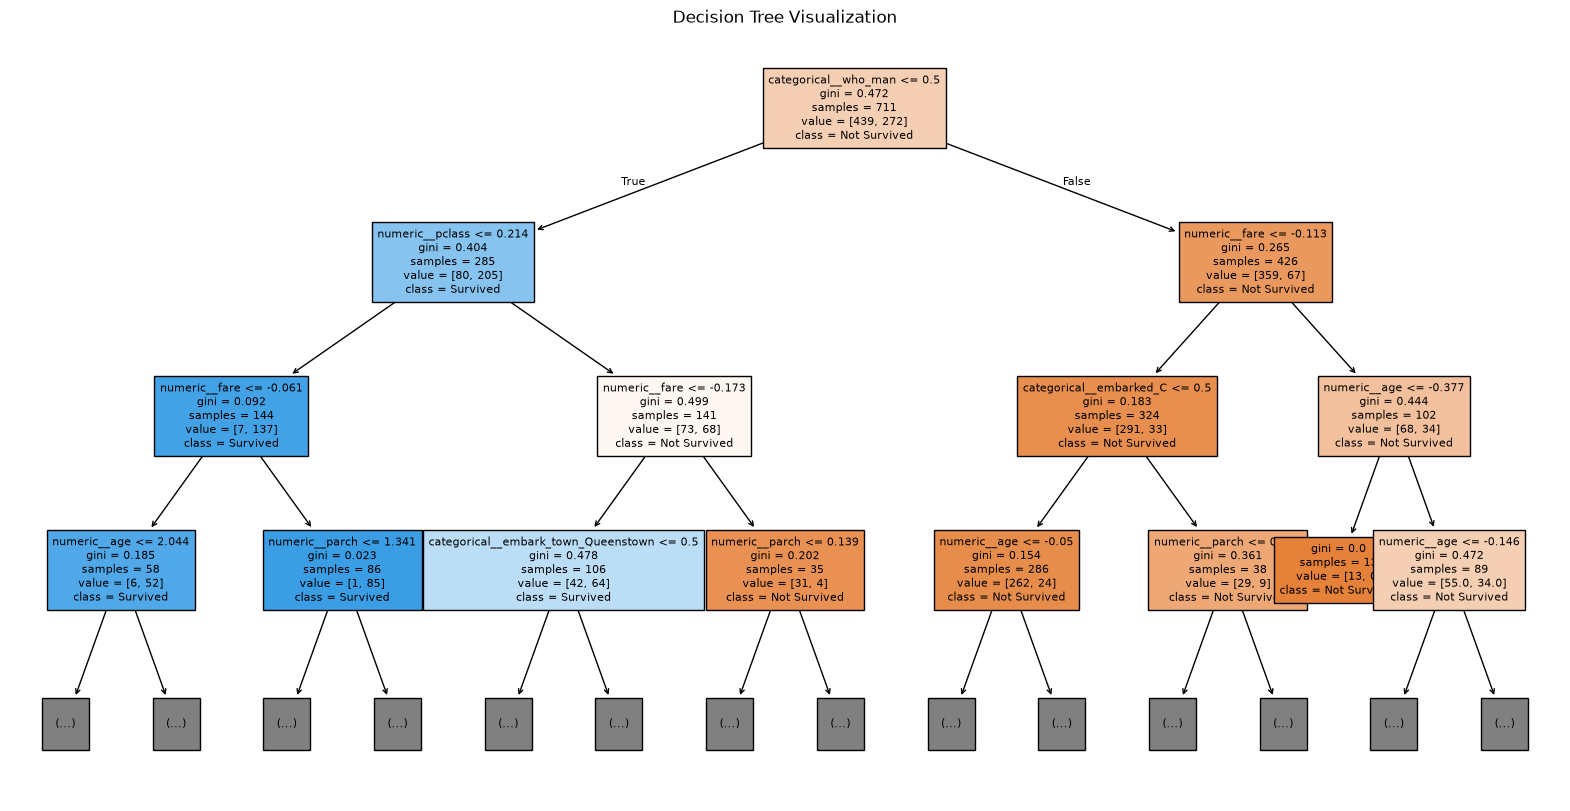

In [22]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

decision_tree_pipeline = pipelines["Decision Tree"]

preprocessor_fitted = decision_tree_pipeline.named_steps["preprocessor"]
decision_tree_model = decision_tree_pipeline.named_steps["model"]

X_train_transformed = preprocessor_fitted.transform(X_train)

feature_names = preprocessor_fitted.get_feature_names_out()

plt.figure(figsize=(20, 10))

plot_tree(
    decision_tree_model,
    feature_names=feature_names,
    class_names=["Not Survived", "Survived"],
    filled=True,
    max_depth=3,
    fontsize=8
)

plt.title("Decision Tree Visualization")
plt.show()

In [23]:
print("Class distribution:")
print(y.value_counts())

print("\nClass proportions:")
print(y.value_counts(normalize=True).round(4))

Class distribution:
survived
0    549
1    340
Name: count, dtype: int64

Class proportions:
survived
0    0.6175
1    0.3825
Name: proportion, dtype: float64


In [24]:
from sklearn.metrics import precision_score, recall_score, f1_score

baseline_model = pipelines["Logistic Regression"]

y_pred_baseline = baseline_model.predict(X_test)

baseline_precision = precision_score(y_test, y_pred_baseline)
baseline_recall = recall_score(y_test, y_pred_baseline)
baseline_f1 = f1_score(y_test, y_pred_baseline)

print("Baseline Logistic Regression")
print("Precision:", round(baseline_precision, 4))
print("Recall:", round(baseline_recall, 4))
print("F1 Score:", round(baseline_f1, 4))

Baseline Logistic Regression
Precision: 0.7966
Recall: 0.6912
F1 Score: 0.7402


In [25]:
balanced_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

balanced_model.fit(X_train, y_train)

y_pred_balanced = balanced_model.predict(X_test)

balanced_precision = precision_score(y_test, y_pred_balanced)
balanced_recall = recall_score(y_test, y_pred_balanced)
balanced_f1 = f1_score(y_test, y_pred_balanced)

print("Balanced Logistic Regression")
print("Precision:", round(balanced_precision, 4))
print("Recall:", round(balanced_recall, 4))
print("F1 Score:", round(balanced_f1, 4))

Balanced Logistic Regression
Precision: 0.7879
Recall: 0.7647
F1 Score: 0.7761


In [27]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

smote_model = ImbPipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

smote_model.fit(X_train, y_train)

y_pred_smote = smote_model.predict(X_test)

smote_precision = precision_score(y_test, y_pred_smote)
smote_recall = recall_score(y_test, y_pred_smote)
smote_f1 = f1_score(y_test, y_pred_smote)

print("SMOTE Logistic Regression")
print("Precision:", round(smote_precision, 4))
print("Recall:", round(smote_recall, 4))
print("F1 Score:", round(smote_f1, 4))

SMOTE Logistic Regression
Precision: 0.7812
Recall: 0.7353
F1 Score: 0.7576


In [28]:
imbalance_results = pd.DataFrame({
    "Approach": [
        "Baseline",
        "Class Weight Balanced",
        "SMOTE"
    ],
    "Precision": [
        baseline_precision,
        balanced_precision,
        smote_precision
    ],
    "Recall": [
        baseline_recall,
        balanced_recall,
        smote_recall
    ],
    "F1 Score": [
        baseline_f1,
        balanced_f1,
        smote_f1
    ]
})

print(imbalance_results.round(4))

                Approach  Precision  Recall  F1 Score
0               Baseline     0.7966  0.6912    0.7402
1  Class Weight Balanced     0.7879  0.7647    0.7761
2                  SMOTE     0.7812  0.7353    0.7576


In [29]:
from sklearn.model_selection import GridSearchCV

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        random_state=42,
        oob_score=True
    ))
])

param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__max_features": ["sqrt", "log2"]
}

rf_grid = GridSearchCV(
    rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best Parameters:")
print(rf_grid.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(round(rf_grid.best_score_, 4))

best_rf = rf_grid.best_estimator_

print("\nOOB Score:")
print(round(best_rf.named_steps["model"].oob_score_, 4))

Best Parameters:
{'model__max_depth': 10, 'model__max_features': 'sqrt', 'model__n_estimators': 200}

Best Cross-Validation F1 Score:
0.7494

OOB Score:
0.82


In [31]:
from sklearn.model_selection import train_test_split

X_reg = df.drop(columns=["fare", "survived", "alive", "class", "age_group"])
y_reg = df["fare"]

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

print("Regression training set:", X_reg_train.shape)
print("Regression test set:", X_reg_test.shape)

Regression training set: (711, 10)
Regression test set: (178, 10)


In [32]:
from sklearn.linear_model import LinearRegression

reg_numeric_features = X_reg_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

reg_categorical_features = X_reg_train.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

reg_numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

reg_categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

reg_preprocessor = ColumnTransformer([
    ("numeric", reg_numeric_pipeline, reg_numeric_features),
    ("categorical", reg_categorical_pipeline, reg_categorical_features)
])

regression_pipeline = Pipeline([
    ("preprocessor", reg_preprocessor),
    ("model", LinearRegression())
])

print("Regression pipeline created successfully!")

Regression pipeline created successfully!


C:\Users\Admin\AppData\Local\Temp\ipykernel_14564\3451175848.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  reg_categorical_features = X_reg_train.select_dtypes(


In [33]:
regression_pipeline.fit(X_reg_train, y_reg_train)

y_reg_pred = regression_pipeline.predict(X_reg_test)

print("Regression model trained successfully!")

Regression model trained successfully!


In [34]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_reg_test, y_reg_pred)
rmse = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred))
r2 = r2_score(y_reg_test, y_reg_pred)

n = len(y_reg_test)
p = X_reg_test.shape[1]

adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))

print("Regression Metrics")
print("MAE:", round(mae, 4))
print("RMSE:", round(rmse, 4))
print("R²:", round(r2, 4))
print("Adjusted R²:", round(adjusted_r2, 4))

Regression Metrics
MAE: 21.255
RMSE: 42.4939
R²: 0.3232
Adjusted R²: 0.2826


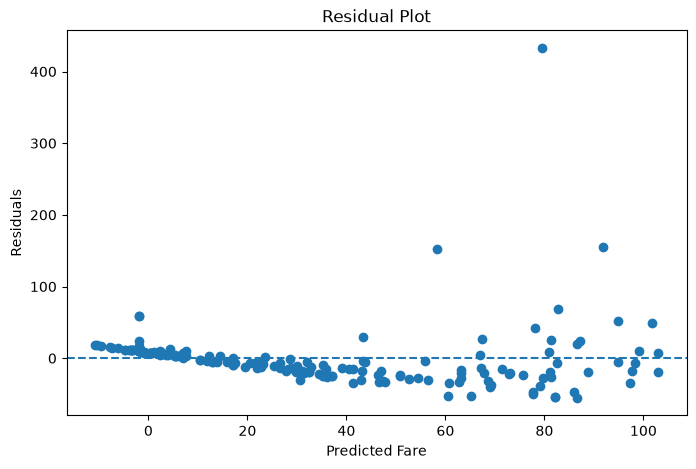

In [35]:
residuals = y_reg_test - y_reg_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_reg_pred, residuals)

plt.axhline(0, linestyle="--")

plt.xlabel("Predicted Fare")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

In [36]:
best_rf_pred = best_rf.predict(X_test)
best_rf_prob = best_rf.predict_proba(X_test)[:, 1]

best_rf_accuracy = accuracy_score(y_test, best_rf_pred)
best_rf_precision = precision_score(y_test, best_rf_pred)
best_rf_recall = recall_score(y_test, best_rf_pred)
best_rf_f1 = f1_score(y_test, best_rf_pred)
best_rf_auc = roc_auc_score(y_test, best_rf_prob)

print("Tuned Random Forest Metrics")
print("Accuracy:", round(best_rf_accuracy, 4))
print("Precision:", round(best_rf_precision, 4))
print("Recall:", round(best_rf_recall, 4))
print("F1 Score:", round(best_rf_f1, 4))
print("ROC-AUC:", round(best_rf_auc, 4))

Tuned Random Forest Metrics
Accuracy: 0.7978
Precision: 0.7667
Recall: 0.6765
F1 Score: 0.7188
ROC-AUC: 0.8154


In [37]:
final_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Tuned Random Forest"
    ],
    "Accuracy": [
        0.8146,
        0.8034,
        0.7921,
        best_rf_accuracy
    ],
    "Precision": [
        0.7966,
        0.7463,
        0.7385,
        best_rf_precision
    ],
    "Recall": [
        0.6912,
        0.7353,
        0.7059,
        best_rf_recall
    ],
    "F1 Score": [
        0.7402,
        0.7407,
        0.7218,
        best_rf_f1
    ],
    "ROC-AUC": [
        0.8678,
        0.7850,
        0.8140,
        best_rf_auc
    ]
})

print(final_results.round(4))

                 Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
0  Logistic Regression    0.8146     0.7966  0.6912    0.7402   0.8678
1        Decision Tree    0.8034     0.7463  0.7353    0.7407   0.7850
2        Random Forest    0.7921     0.7385  0.7059    0.7218   0.8140
3  Tuned Random Forest    0.7978     0.7667  0.6765    0.7188   0.8154


### Classifier Recommendation

Among the tested models, Logistic Regression achieved the highest accuracy of **81.46%** and ROC-AUC of **0.8678**. The class-weight-balanced Logistic Regression improved recall from **0.6912 to 0.7647** and F1 score from **0.7402 to 0.7761**, which shows better performance on the survival class. The tuned Random Forest did not improve the overall results compared with Logistic Regression. Based on these evaluation results, the class-weight-balanced Logistic Regression can be selected as the final model because it provides a better balance between precision, recall, and F1 score.


In [38]:
import joblib

joblib.dump(
    balanced_model,
    "best_titanic_pipeline.joblib"
)

print("Best pipeline saved successfully!")

Best pipeline saved successfully!


In [39]:
loaded_pipeline = joblib.load("best_titanic_pipeline.joblib")

sample_passenger = X_test.iloc[[0]]

prediction = loaded_pipeline.predict(sample_passenger)

print("Prediction:", prediction[0])

Prediction: 0
